# Examples of different classifiers

In [78]:
import numpy as np
import numpy.random as rnd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import norm
import scipy.stats as stats
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier





# Generate some random data




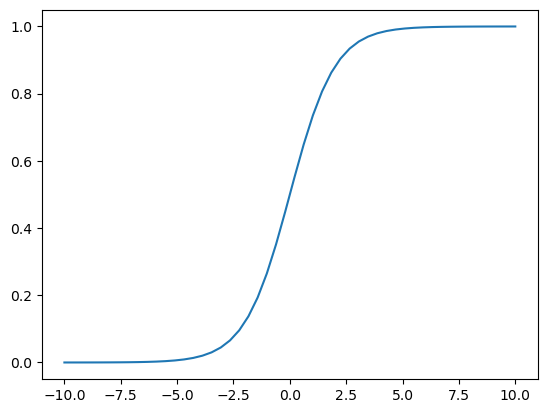

In [79]:
def sigmoid(x):
    return(1/(1+np.exp(-x)))

x = np.linspace(-10,10)
plt.plot(x,sigmoid(x))




In [80]:
# Define parameters
# return x[1]-(a*x[0]+b) where a,b = bounds[0], bounds[1]
# this is positive if above the line y=ax+b, and negative if below the line
def in_region(x, bounds=[-1,2]):    
    return( x[1] - bounds[0]*x[0] - bounds[1])


# def in_region(x, bounds=[-3,3]):    
#     return( -1*x[1]- bounds[0]*x[0]**2 - bounds[1])





Generate data points $(X_i, Y_i)$ for $i=1,\ldots, n$ with $X_i \in \mathbb{R}^2$ and $Y_i \in \{0,1\}$. Given $X_i$,  $Y_i$ is a binomial random variable taking value $1$ with probability $\mathrm{sigmoid}(f(X_i))$ for some function $f:\mathbb{R}^2 \to \mathbb{R}$.

e.g. $f(x_1,x_2) = x_2 - (ax_1+b)$.

In [70]:
# Generate random points

def generate_data(n, bounds = [-2,3,-4,5]):
    X = np.zeros((n,2))
    
    #generate X_i at random from the rectangle [b0, b1] x [b2, b3]
    for i in range(n):
        X[i,0] = rnd.uniform(bounds[0],bounds[1])
        X[i,1] = rnd.uniform(bounds[2],bounds[3])
        
    # Y takes value 0 or 1
    Y = np.zeros(n)
    for i in range(n):
        y = in_region(X[i,:])
        Y[i] = rnd.binomial(1,sigmoid(2*y))
    return X,Y

n = 200 #number of data points
X,Y = generate_data(n)
    
blues = X[Y==1,:]
reds = X[Y==0,:]





Plot the data points $X_i$, with blue points denoting when $Y_i = 1$ and red points when $Y_i = 0$.

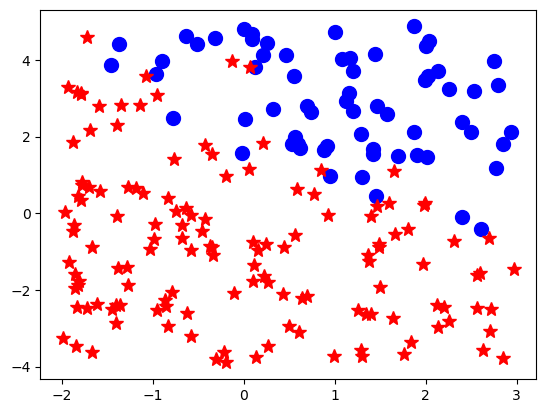

In [71]:
fig, ax = plt.subplots(1)
ax.plot(blues[:,0],blues[:,1],'bo', reds[:,0],reds[:,1],'r*', markersize=10)
plt.show()



# Apply 3 classifiers:

- SVM where the classifier is of the form $h(x) = \mathrm{Sign}(w^\top x - b)$ for some $w\in \mathbb{R}^d$ and $b\in \mathbb{R}$.
- Kernel SVM where the classifier is of the form 
$$
h(x) =\mathrm{Sign}\left( \sum_i c_i \exp(-\gamma \|x-x_i\|^2) + d \right),
$$
for some $c_i\in\mathbb{R}$ and $d\in\mathbb{R}$. Equivalent to assuming that $h(x) = \mathrm{Sign}( w^\top \phi(x) + b)$ for some $b\in \mathbb{R}$ and $\phi:\mathbb{R}^d \to \mathcal{H}$ mapping to some Hilbert space.
- K-nearest neighbours.

In [72]:
clf_linSVM = svm.LinearSVC()
clf_linSVM.fit(X, Y)

clf_kernel = svm.SVC(kernel='rbf', gamma= .5)
clf_kernel.fit(X, Y)

clf_KNN = KNeighborsClassifier(n_neighbors=1)
clf_KNN.fit(X, Y)


classifiers = [clf_linSVM, clf_kernel, clf_KNN]
labels = ['linear', 'kernel', 'KNN']



/Users/u2272691/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


# Show the decision boundaries. 

We will evaluate the classifier on a grid and display the classifier output.

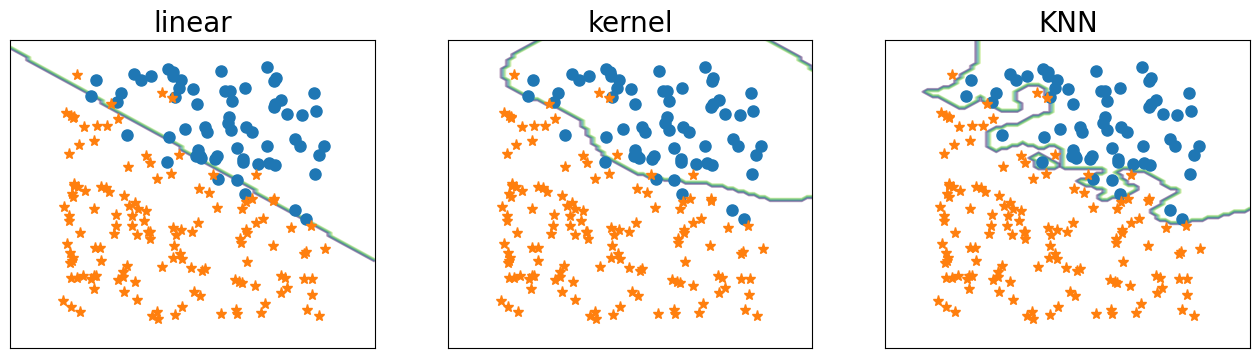

In [73]:
# Plotting decision regions

#generate grid points [x_min, x_max] by [y_min, y_max]
x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1
x0, x1 = np.meshgrid(np.arange(x0_min, x0_max, 0.1), np.arange(x1_min, x1_max, 0.1))

fig, ax = plt.subplots(1,3, figsize=(16,4))

#now run each classifier on the grid and plot the decision boundary
for i in range(len(classifiers)):
    
    clf = classifiers[i]
    
    #apply the classifier to the data points
    Z = clf.predict(np.c_[x0.ravel(), x1.ravel()])    
    Z = Z.reshape(x0.shape)
    
    #draw a contour plot to show where the decision boundary is
    ax[i].contour(x0, x1, Z, alpha=0.3)
    
    #plot the original data points that the classifier was trained on
    ax[i].plot(blues[:,0],blues[:,1],'o', reds[:,0],reds[:,1],'*', markersize='8')
    
    #label the figure
    ax[i].set_title(labels[i], fontsize=20)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.savefig('difclass.pdf')



In [74]:
for clf, label in zip(classifiers, labels):
    print( "Accuracy of " + label + " on training: ", sum(Y == clf.predict(X))/n)



Accuracy of linear on training:  0.94
Accuracy of kernel on training:  0.935
Accuracy of KNN on training:  1.0


# Accuracy on test data

In [75]:
# Generate random test data
# Generate random points and label them
n_test = 10000
X_test,Y_test = generate_data(n_test)
blues_test = X_test[Y_test==1,:]
reds_test = X_test[Y_test==0,:]



In [76]:


for clf, label in zip(classifiers, labels):
    print( "Accuracy of " + label + " on test: ", sum(Y_test == clf.predict(X_test))/n_test)


Accuracy of linear on test:  0.918
Accuracy of kernel on test:  0.9057
Accuracy of KNN on test:  0.8869


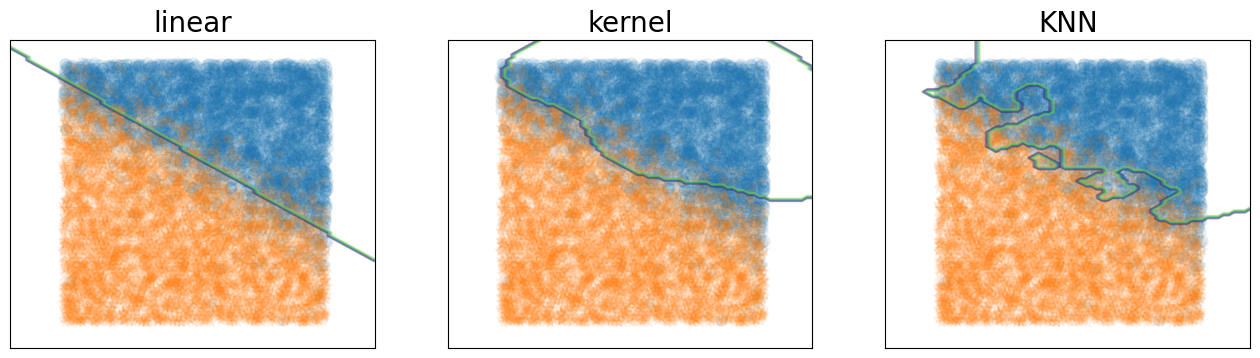

In [77]:

    
# Plotting decision regions

#generate grid points [x_min, x_max] by [y_min, y_max]
x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1
x0, x1 = np.meshgrid(np.arange(x0_min, x0_max, 0.1), np.arange(x1_min, x1_max, 0.1))

fig, ax = plt.subplots(1,3, figsize=(16,4))

#now run each classifier on the grid and plot the decision boundary
for i in range(len(classifiers)):
    
    clf = classifiers[i]
    
    #apply the classifier to the data points
    Z = clf.predict(np.c_[x0.ravel(), x1.ravel()])    
    Z = Z.reshape(x0.shape)
    
    
    #plot the  data points that the classifier was tested on
    ax[i].plot(blues_test[:,0],blues_test[:,1],'o', reds_test[:,0],reds_test[:,1],'*', markersize='8', alpha=0.08)
    
    #draw a contour plot to show where the decision boundary is
    ax[i].contour(x0, x1, Z, alpha=0.3)
    
    #label the figure
    ax[i].set_title(labels[i], fontsize=20)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.savefig('difclass.pdf')
